In [ ]:
# Requires a kaggle.json API token in ~/.kaggle/ (or set KAGGLE_USERNAME / KAGGLE_KEY env vars)
# On Colab, upload kaggle.json first:
# from google.colab import files
# files.upload()
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

!pip install -q kaggle
!kaggle datasets download msambare/fer2013
!unzip -q -o fer2013.zip -d fer2013_data
!ls fer2013_data

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:03<00:00, 15.9MB/s]

test  train


In [ ]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cpu":
    print("WARNING: no GPU detected. Training will be very slow (many minutes per epoch).")

DATA_DIR = "fer2013_data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")

BATCH_SIZE = 64
NUM_EPOCHS = 30
NUM_CLASSES = 7
LR = 1e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1     # used only for the training loss, not the eval loss
DROPOUT_P = 0.25
EARLY_STOP_PATIENCE = 6
OVERFIT_GAP_LIMIT = 0.20  # hard stop if train_acc - val_acc exceeds this
LOSS_TIE_TOLERANCE = 0.01 # NEW: if val loss is within this of the best, prefer higher val acc
IMG_SIZE = 224
NUM_WORKERS = 2   # set to 0 if DataLoader workers hang/crash on your platform

Using device: cuda


In [ ]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train samples: 28709
Test samples: 7178


In [ ]:
from collections import Counter

targets = [label for _, label in train_dataset.samples]
class_counts = Counter(targets)
counts_ordered = np.array([class_counts[i] for i in range(NUM_CLASSES)], dtype=np.float32)

raw_weights = counts_ordered.sum() / (NUM_CLASSES * counts_ordered)
class_weights = np.sqrt(raw_weights)
class_weights = class_weights / class_weights.mean()
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

for name, count, w_raw, w in zip(class_names, counts_ordered, raw_weights, class_weights):
    print(f"{name:10s} count={int(count):5d}  raw_weight={w_raw:.3f}  sqrt_weight={w:.3f}")

angry      count= 3995  raw_weight=1.027  sqrt_weight=0.806
disgust    count=  436  raw_weight=9.407  sqrt_weight=2.439
fear       count= 4097  raw_weight=1.001  sqrt_weight=0.796
happy      count= 7215  raw_weight=0.568  sqrt_weight=0.600
neutral    count= 4965  raw_weight=0.826  sqrt_weight=0.723
sad        count= 4830  raw_weight=0.849  sqrt_weight=0.733
surprise   count= 3171  raw_weight=1.293  sqrt_weight=0.904


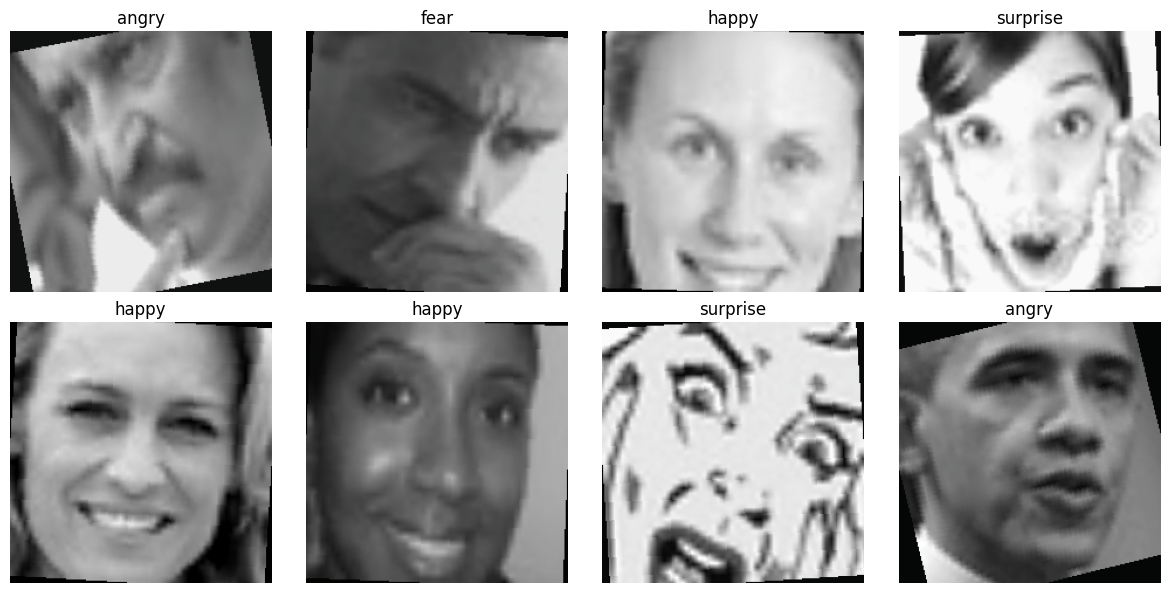

In [ ]:
import matplotlib.pyplot as plt

def imshow(img_tensor, mean, std):
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    return np.clip(img, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(imshow(images[i], np.array(imagenet_mean), np.array(imagenet_std)))
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=DROPOUT_P),
    nn.Linear(num_features, NUM_CLASSES)
)

frozen_layers = ["conv1", "bn1", "layer1"]
for name, param in model.named_parameters():
    if any(name.startswith(layer) for layer in frozen_layers):
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

model = model.to(device)

# Training loss: class-weighted + label smoothing (helps generalization during optimization)
criterion_train = nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=LABEL_SMOOTHING)

# Eval loss: class-weighted, NO label smoothing -> a clean, comparable signal for early stopping
criterion_eval = nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=0.0)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


Trainable params: 11,022,599 / 11,180,103


In [ ]:
def train_model(model, criterion_train, criterion_eval, optimizer, scheduler,
                 num_epochs, patience, gap_limit, loss_tie_tolerance):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    best_val_acc = 0.0
    epochs_no_improve = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        epoch_train_acc = None
        epoch_val_acc = None

        for phase, loader in [("train", train_loader), ("val", test_loader)]:
            model.train() if phase == "train" else model.eval()
            criterion = criterion_train if phase == "train" else criterion_eval

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc = (running_corrects.double() / len(loader.dataset)).item()

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}"
                  + ("  (unsmoothed)" if phase == "val" else "  (smoothed)"))

            if phase == "train":
                epoch_train_acc = epoch_acc
            else:
                epoch_val_acc = epoch_acc
                scheduler.step(epoch_loss)

                is_clear_improvement = epoch_loss < best_val_loss - loss_tie_tolerance
                is_tied_but_better_acc = (
                    abs(epoch_loss - best_val_loss) <= loss_tie_tolerance
                    and epoch_acc > best_val_acc
                )

                if is_clear_improvement or is_tied_but_better_acc:
                    reason = "clear loss improvement" if is_clear_improvement else "tie-break on higher val acc"
                    print(f"  -> new best checkpoint ({reason})")
                    best_val_loss = min(best_val_loss, epoch_loss)
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        gap = epoch_train_acc - epoch_val_acc
        print(f"train/val accuracy gap: {gap:.4f}")
        print()

        if gap > gap_limit:
            print(f"Hard overfitting guard triggered after epoch {epoch+1} "
                  f"(train/val gap {gap:.4f} > {gap_limit})")
            break

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after epoch {epoch+1} "
                  f"(no checkpoint improvement for {patience} epochs)")
            break

    print(f"Best val Loss: {best_val_loss:.4f}  Best val Acc: {best_val_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history

model, history = train_model(
    model, criterion_train, criterion_eval, optimizer, scheduler,
    NUM_EPOCHS, EARLY_STOP_PATIENCE, OVERFIT_GAP_LIMIT, LOSS_TIE_TOLERANCE
)

Epoch 1/30
--------------------
train Loss: 1.5934 Acc: 0.4994  (smoothed)
val Loss: 1.1286 Acc: 0.5836  (unsmoothed)
  -> new best checkpoint (clear loss improvement)
train/val accuracy gap: -0.0842

Epoch 2/30
--------------------
train Loss: 1.3989 Acc: 0.6006  (smoothed)
val Loss: 1.0281 Acc: 0.6307  (unsmoothed)
  -> new best checkpoint (clear loss improvement)
train/val accuracy gap: -0.0301

Epoch 3/30
--------------------
train Loss: 1.3227 Acc: 0.6378  (smoothed)
val Loss: 0.9925 Acc: 0.6434  (unsmoothed)
  -> new best checkpoint (clear loss improvement)
train/val accuracy gap: -0.0055

Epoch 4/30
--------------------
train Loss: 1.2747 Acc: 0.6601  (smoothed)
val Loss: 0.9794 Acc: 0.6569  (unsmoothed)
  -> new best checkpoint (clear loss improvement)
train/val accuracy gap: 0.0032

Epoch 5/30
--------------------
train Loss: 1.2320 Acc: 0.6852  (smoothed)
val Loss: 0.9807 Acc: 0.6578  (unsmoothed)
  -> new best checkpoint (tie-break on higher val acc)
train/val accuracy gap: 

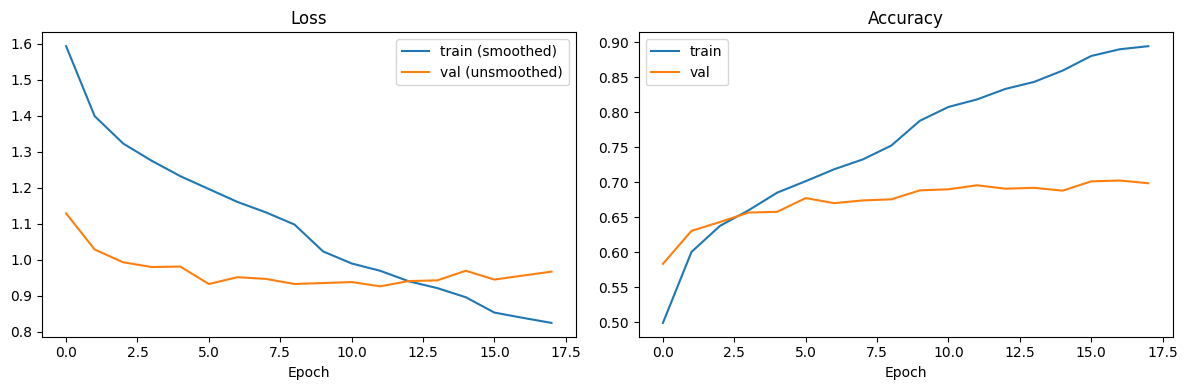

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train (smoothed)")
axes[0].plot(history["val_loss"], label="val (unsmoothed)")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

       angry       0.58      0.64      0.61       958
     disgust       0.75      0.72      0.74       111
        fear       0.65      0.44      0.52      1024
       happy       0.87      0.89      0.88      1774
     neutral       0.62      0.70      0.66      1233
         sad       0.58      0.58      0.58      1247
    surprise       0.81      0.82      0.81       831

    accuracy                           0.70      7178
   macro avg       0.69      0.69      0.69      7178
weighted avg       0.70      0.70      0.69      7178



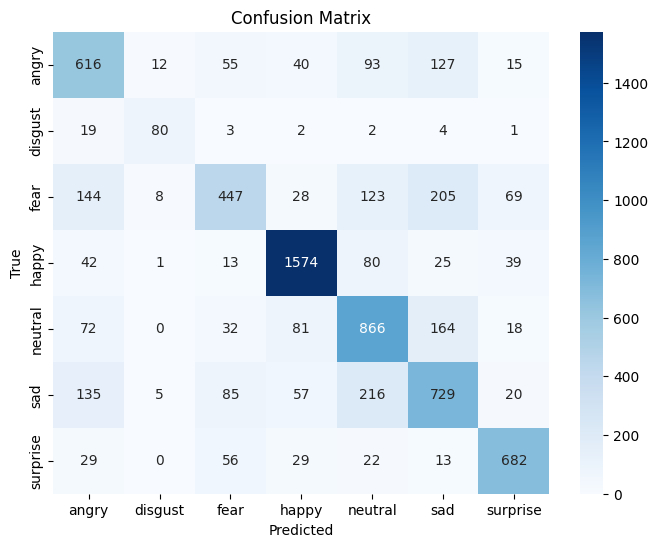

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
torch.save(model.state_dict(), "resnet18_fer2013_v6.pth")
print("Model saved to resnet18_fer2013_v6.pth")

Model saved to resnet18_fer2013_v6.pth


In [ ]:
from PIL import Image

def predict_emotion(image_path, model, transform, class_names):
    model.eval()
    img = Image.open(image_path).convert("L")
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_t)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
    return class_names[pred_idx], probs.cpu().numpy()

# Example usage:
# emotion, probs = predict_emotion("path/to/face.jpg", model, test_transform, class_names)
# print(emotion, probs)